# Grad-CAM: pesi vecchi vs pesi nuovi sulle STESSE coppie

Nessuno split, nessun dataloader, nessun calcolo su tutto il test set:
si caricano solo le 4 coppie (8 immagini) già mostrate nei plot dei
failure case, e si calcola la Grad-CAM con ciascun checkpoint.

Riempi solo la cella CONFIG (path dei checkpoint, embedding_dim, soglia).

In [1]:
import sys
sys.path.append('/home/lorenzo/Documenti/GitHub/HandVerify')

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image

from src.models import get_model
from src.data.transforms import get_test_transforms
from src.interpretability import compute_pairwise_gradcam, overlay_cam_on_image
from src.utils import get_device

device = get_device()

Using device: cpu


## CONFIG

In [ ]:
BACKBONE = "mobilenet_v3_small"
LOSS_TYPE = "contrastive"
TARGET_SIZE = 448
FREEZE_LAYERS = 3
DROPOUT = 0.2

# cartella in cui cercare le immagini per nome file (una sola scansione)
IMAGES_ROOT = Path("/home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed")
OUTPUT_DIR = Path("./gradcam_compare")

RESULTS = Path("/home/lorenzo/Documenti/GitHub/HandVerify/results")
RESULTS2 = Path("/home/lorenzo/Documenti/GitHub/HandVerify/results2")
EXP = BACKBONE + '_' + LOSS_TYPE + "_iam_to_iam"

# "threshold": un float, oppure il path di un *_final_metrics.csv da cui
# leggere eer_threshold. "embedding_dim" può essere diverso tra i due modelli.
MODELS = {
    "vecchi": {
        "checkpoint": RESULTS / "contrastive" / "contrastive_experiments" / EXP / f"{EXP}_best.pth",
        "threshold": 0.6469,          # quella riportata nei plot originali
        "embedding_dim": 32,
    },
    "nuovi": {
        "checkpoint": RESULTS2 / "contrastive" / "contrastive_experiments" / EXP / f"{EXP}_best.pth",
        "threshold": 0.535,      # <-- da compilare (o un float)
        "embedding_dim": 32,
    },
}

# Le coppie esattamente come nei plot (img1, img2, label vera)
PAIRS = {
    "false_accepts": [
        ("k03-117_full.png", "r02-065_full.png", "impostor"),
        ("l01-065_full.png", "r02-065_full.png", "impostor"),
    ],
    "false_rejects": [
        ("g01-004_full.png", "g01-008_full.png", "genuine"),
        ("h06-079_full.png", "h06-085_full.png", "genuine"),
    ],
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Localizza le 8 immagini per nome file

In [15]:
index = {}
for p in IMAGES_ROOT.rglob("*.png"):
    index.setdefault(p.name, []).append(p)

def resolve(name):
    matches = index.get(name, [])
    if len(matches) != 1:
        raise RuntimeError(
            f"'{name}': trovati {len(matches)} file in {IMAGES_ROOT}: {matches}. "
            f"Se >1, sostituisci il nome in PAIRS con il path completo."
        )
    return matches[0]

resolved = {
    group: [(resolve(a), resolve(b), label) for a, b, label in pairs]
    for group, pairs in PAIRS.items()
}
for group, pairs in resolved.items():
    for a, b, _ in pairs:
        print(f"{group}: {a}  |  {b}")

false_accepts: /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/431/k03-117_full.png  |  /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/644/r02-065_full.png
false_accepts: /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/461/l01-065_full.png  |  /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/644/r02-065_full.png
false_rejects: /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/295/g01-004_full.png  |  /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/295/g01-008_full.png
false_rejects: /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/384/h06-079_full.png  |  /home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten/iam_processed/384/h06-085_full.png


## Caricamento modelli e utilità

In [16]:
transform = get_test_transforms(TARGET_SIZE)

def load_tensor(path):
    img = Image.open(path).convert("L")
    return transform(img).unsqueeze(0).to(device)

def load_gray_uint8(path):
    # stessa risoluzione vista dal modello, così la CAM combacia
    return np.array(Image.open(path).convert("L").resize((TARGET_SIZE, TARGET_SIZE)))

def resolve_threshold(t):
    if isinstance(t, (int, float)):
        return float(t)
    return float(pd.read_csv(t)["eer_threshold"].values[0])

def load_model(cfg):
    model = get_model(
        BACKBONE, model_type=LOSS_TYPE,
        in_channels=1, freeze_backbone_layers=FREEZE_LAYERS,
        dropout=DROPOUT, embedding_dim=cfg["embedding_dim"],
    )
    model.load_state_dict(torch.load(cfg["checkpoint"], map_location=device))
    return model.to(device).eval()

loaded = {}
for tag, cfg in MODELS.items():
    loaded[tag] = (load_model(cfg), resolve_threshold(cfg["threshold"]))
    print(f"✓ {tag}: soglia EER = {loaded[tag][1]:.4f}")

Total encoder layers: 13
  ❄️  Frozen 3 encoder layers
  ❄️  Frozen parameters: 4,784 / 926,720 (0.5%)


RuntimeError: Error(s) in loading state_dict for ContrastiveMobileNetV3Small:
	Missing key(s) in state_dict: "encoder.0.0.0.weight", "encoder.0.0.1.weight", "encoder.0.0.1.bias", "encoder.0.0.1.running_mean", "encoder.0.0.1.running_var", "encoder.0.1.block.0.0.weight", "encoder.0.1.block.0.1.weight", "encoder.0.1.block.0.1.bias", "encoder.0.1.block.0.1.running_mean", "encoder.0.1.block.0.1.running_var", "encoder.0.1.block.1.fc1.weight", "encoder.0.1.block.1.fc1.bias", "encoder.0.1.block.1.fc2.weight", "encoder.0.1.block.1.fc2.bias", "encoder.0.1.block.2.0.weight", "encoder.0.1.block.2.1.weight", "encoder.0.1.block.2.1.bias", "encoder.0.1.block.2.1.running_mean", "encoder.0.1.block.2.1.running_var", "encoder.0.2.block.0.0.weight", "encoder.0.2.block.0.1.weight", "encoder.0.2.block.0.1.bias", "encoder.0.2.block.0.1.running_mean", "encoder.0.2.block.0.1.running_var", "encoder.0.2.block.1.0.weight", "encoder.0.2.block.1.1.weight", "encoder.0.2.block.1.1.bias", "encoder.0.2.block.1.1.runnin

## Grad-CAM e griglia di confronto
Per ogni coppia: una riga con [modello A: img1, img2 | modello B: img1, img2].
Il titolo indica score, soglia ed esito (✓ corretto / ✗ errore).

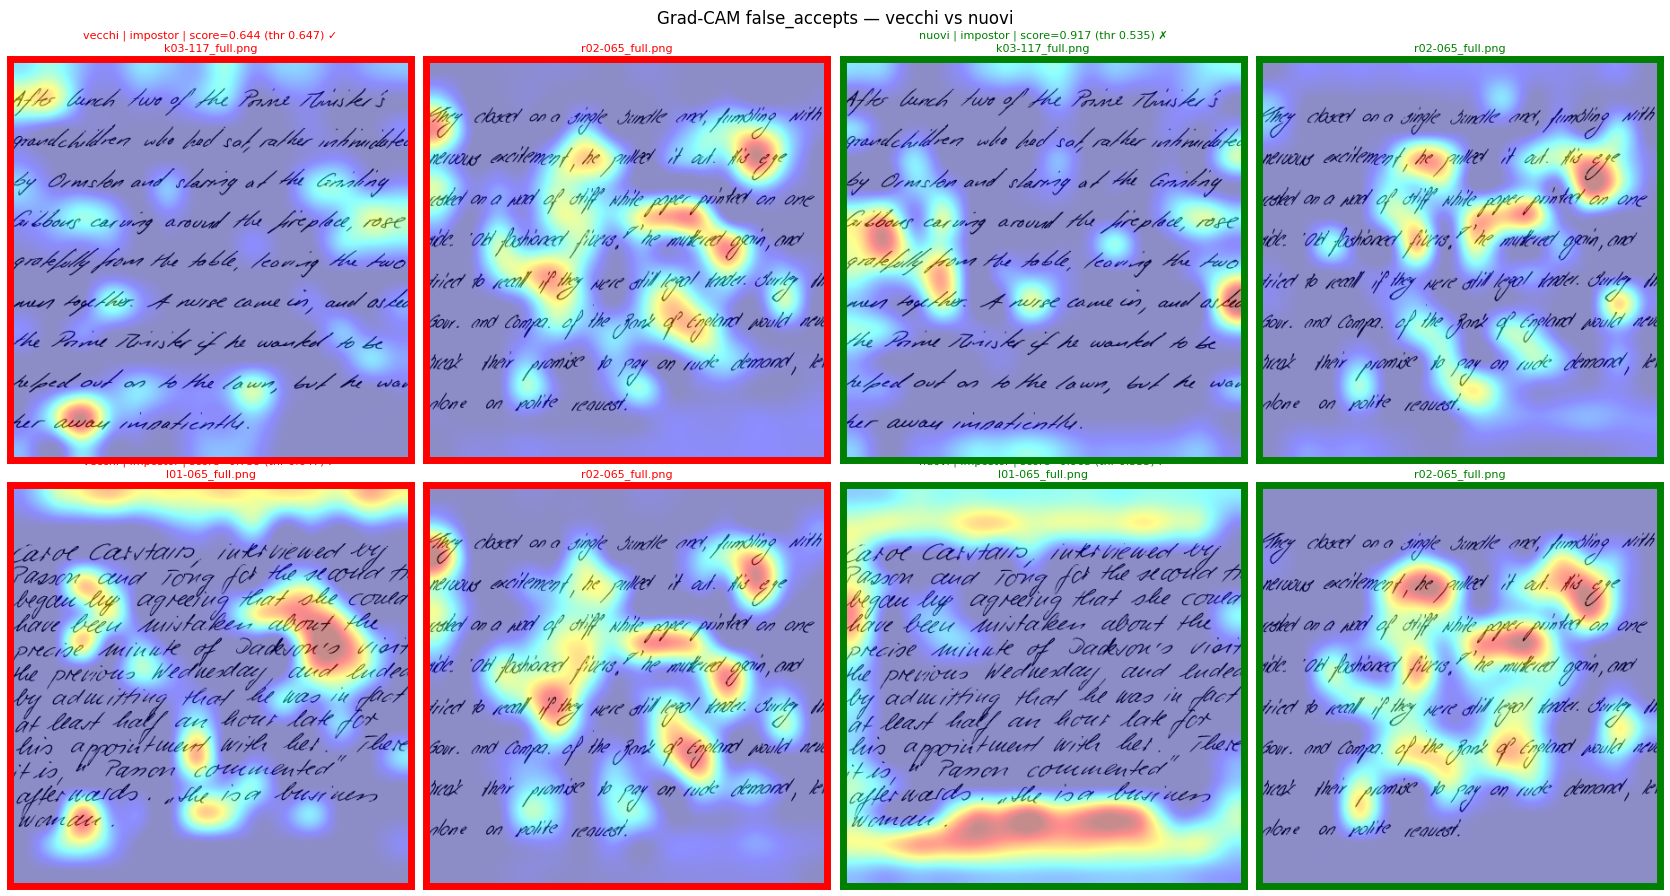

✓ Salvato: gradcam_compare/gradcam_compare_false_accepts.png


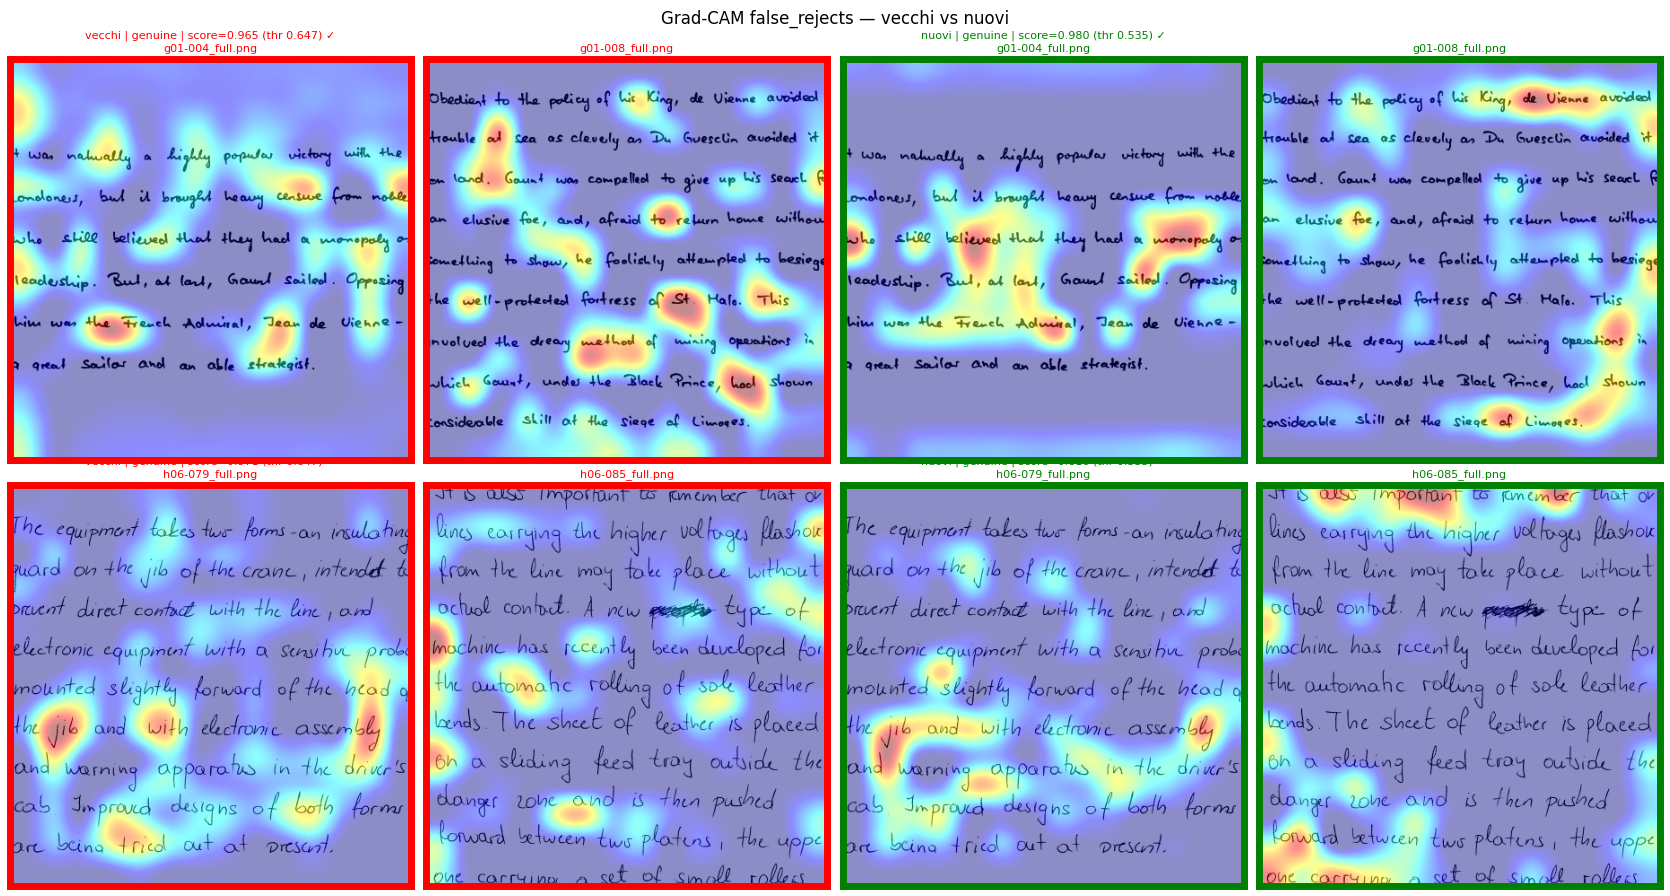

✓ Salvato: gradcam_compare/gradcam_compare_false_rejects.png


In [13]:
FRAME_COLORS = {"vecchi": "red", "nuovi": "green"}
 
def plot_group(group, pairs):
    tags = list(loaded.keys())
    n = len(pairs)
    fig, axes = plt.subplots(n, 2 * len(tags), figsize=(4.2 * 2 * len(tags), 4.6 * n), squeeze=False)
    rows = []
 
    for i, (p1, p2, label) in enumerate(pairs):
        t1, t2 = load_tensor(p1), load_tensor(p2)
        g1, g2 = load_gray_uint8(p1), load_gray_uint8(p2)
 
        for j, tag in enumerate(tags):
            model, thr = loaded[tag]
            cam1, cam2, score = compute_pairwise_gradcam(model, LOSS_TYPE, t1, t2, device)
            ok = (score >= thr) == (label == "genuine")
 
            for k, (g, cam, p) in enumerate([(g1, cam1, p1), (g2, cam2, p2)]):
                ax = axes[i, 2 * j + k]
                ax.imshow(cv2.cvtColor(overlay_cam_on_image(g, cam), cv2.COLOR_BGR2RGB))
                color = FRAME_COLORS.get(tag, "black")
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_edgecolor(color)
                    spine.set_linewidth(5)
                head = f"{tag} | {label} | score={score:.3f} (thr {thr:.3f}) {'✓' if ok else '✗'}\n" if k == 0 else "\n"
                ax.set_title(head + p.name, fontsize=8, color=color)
 
            rows.append({"group": group, "img1": p1.name, "img2": p2.name, "label": label,
                         "model": tag, "score": score, "threshold": thr, "correct": ok})
 
    fig.suptitle(f"Grad-CAM {group} — {' vs '.join(tags)}", fontsize=12)
    plt.tight_layout()
    out = OUTPUT_DIR / f"gradcam_compare_{group}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Salvato: {out}")
    return rows
 
all_rows = []
for group, pairs in resolved.items():
    all_rows += plot_group(group, pairs)

## Tabella riassuntiva score vecchi vs nuovi

In [12]:
summary = pd.DataFrame(all_rows)
summary.to_csv(OUTPUT_DIR / "gradcam_compare_scores.csv", index=False)
summary

,group,img1,img2,label,model,score,threshold,correct
0,false_accepts,k03-117_full.png,r02-065_full.png,impostor,vecchi,0.644296,0.6469,True
1,false_accepts,k03-117_full.png,r02-065_full.png,impostor,nuovi,0.917419,0.5350,False
2,false_accepts,l01-065_full.png,r02-065_full.png,impostor,vecchi,0.739450,0.6469,False
3,false_accepts,l01-065_full.png,r02-065_full.png,impostor,nuovi,0.963326,0.5350,False
4,false_rejects,g01-004_full.png,g01-008_full.png,genuine,vecchi,0.964966,0.6469,True
5,false_rejects,g01-004_full.png,g01-008_full.png,genuine,nuovi,0.979798,0.5350,True
6,false_rejects,h06-079_full.png,h06-085_full.png,genuine,vecchi,0.970666,0.6469,True
7,false_rejects,h06-079_full.png,h06-085_full.png,genuine,nuovi,0.815629,0.5350,True
